# Remaining Useful Life Prediction - Uncertainty-Aware and Explainable #

**Topic:** Uncertainty-Aware and Explainable Deep Learning Framework for Remaining Useful Life Prediction in Smart Manufacturing Systems

**Stage:** Uncertainty-Aware and Explainable, explaining which features lead to the prediction while taking into account the uncertainty surrounding predictions

This notebook implements Phase 3 (Uncertainty-Aware RUL Prediction with MC Dropout) and Phase 4 (Explainability via Attention + SHAP) on top of the pretrained LSTM Autoencoder  
encoder from Part 1.

**Prerequisite artifacts from Part 1**:
| File | Contents |
|---|---|
| `pretrained_encoder.pt` | Encoder state-dict |
| `scaler.pkl` | Fitted `MinMaxScaler` |
| `pretraining_config.json` | Hyperparameters and feature list |
| `CMAPSSData.zip` | Raw C-MAPSS dataset |


## Step 1: Install and Import Dependencies ##

In [1]:
!pip install -q shap captum


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.0 MB/s eta 0:00:00


In [2]:
import zipfile, os, pickle, json, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
import pickle as pkl

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import shap

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 110


Using device: cuda


## Step 2: Upload Part 1 Artifacts and C-MAPSS Data ##

Upload the four files saved at the end of Part 1:  
`pretrained_encoder.pt`, `scaler.pkl`, `pretraining_config.json`, `CMAPSSData.zip`


In [3]:
from google.colab import files
uploaded = files.upload()


Saving CMAPSSData.zip to CMAPSSData.zip
Saving pretrained_encoder.pt to pretrained_encoder.pt
Saving pretraining_config.json to pretraining_config.json
Saving scaler.pkl to scaler.pkl


In [4]:
EXTRACT_PATH = "data"
ZIP_PATH = "CMAPSSData.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
  z.extractall(EXTRACT_PATH)

with open("pretraining_config.json") as f:
  cfg = json.load(f)

FEATURE_COLS = cfg["feature_cols"]
N_FEATURES = cfg["n_features"]
WINDOW_SIZE = cfg["window_size"]
HIDDEN_DIM = cfg["hidden_dim"]
LATENT_DIM = cfg["latent_dim"]
NUM_LAYERS = cfg["num_layers"]
DROPOUT = cfg["dropout"]
HEALTHY_FRAC = cfg["healthy_frac"]
STRIDE = cfg["stride"]
THRESHOLD = cfg["anomaly_threshold"]

print("\nConfig loaded: ")
for k, v in cfg.items():
  print(f"{k}: {v}")



Config loaded: 
dataset: C-MAPSS FD001
feature_cols: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
n_features: 14
window_size: 30
stride: 1
healthy_frac: 0.4
hidden_dim: 128
latent_dim: 64
num_layers: 2
dropout: 0.2
best_val_composite_loss: 0.04904127818353502
best_val_mse: 0.009785975329577923
anomaly_threshold: 0.011818692088127136
healthy_mean_mse: 0.009785975329577923
healthy_std_mse: 0.0006775724468752742


## Step 3: Load and Pre-process C-MAPSS FD001 ##

Replicate the same data pipeline from Part 1, then additionally build supervised Window --> Remaining Useful Life samples for the prediction head.

In [5]:
INDEX_COLS = ["unit_id", "cycle"]
SETTING_COLS = ["setting_1", "setting_2", "setting_3"]
SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]
ALL_COLS = INDEX_COLS + SETTING_COLS + SENSOR_COLS

def load_cmapss(data_dir, split = "train", subset = "FD001"):
  candidates = [
    os.path.join(data_dir, f"{split}_{subset}.txt"),
    os.path.join(data_dir, "CMAPSSData", f"{split}_{subset}.txt")
  ]

  path = next((p for p in candidates if os.path.exists(p)), None)
  if path is None:
    raise FileNotFoundError(f"Cannot find {split}_{subset}.txt under {data_dir}")

  df = pd.read_csv(path, sep = r"\s+", header = None, names = ALL_COLS)
  print(f"Loaded {split}_{subset}: {df.shape[0]:,} rows, {df['unit_id'].nunique()} engines")

  return df


In [6]:
df_train_raw = load_cmapss(EXTRACT_PATH, "train")
df_test_raw = load_cmapss(EXTRACT_PATH, "test")

rul_candidates = [
  os.path.join(EXTRACT_PATH, "RUL_FD001.txt"),
  os.path.join(EXTRACT_PATH, "CMAPSSData", "RUL_FD001.txt")
]

rul_path = next((p for p in rul_candidates if os.path.exists(p)), None)
df_rul_test = pd.read_csv(rul_path, header = None, names = ["rul_true"])
print(f"Test RUL labels: {len(df_rul_test)} engines")

Loaded train_FD001: 20,631 rows, 100 engines
Loaded test_FD001: 13,096 rows, 100 engines
Test RUL labels: 100 engines


In [7]:
with open("scaler.pkl", "rb") as f:
  scaler = pickle.load(f)

df_train = df_train_raw.copy()
df_test = df_test_raw.copy()
df_train[FEATURE_COLS] = scaler.transform(df_train_raw[FEATURE_COLS])
df_test[FEATURE_COLS] = scaler.transform(df_test_raw[FEATURE_COLS])

In [8]:
# Cap RUL at 125 cycles (standard for FD001)
# This keeps early cycles from swamping the loss with large targets
RUL_CAP = 125

def add_rul(df):
  df = df.copy()
  max_cycles = df.groupby("unit_id")["cycle"].transform("max")
  df["rul"] = (max_cycles - df["cycle"]).clip(upper = RUL_CAP)

  return df

df_train = add_rul(df_train)
print("RUL column added. Sample: ")
print(df_train[["unit_id", "cycle", "rul"]].head(10))

RUL column added. Sample: 
   unit_id  cycle  rul
0        1      1  125
1        1      2  125
2        1      3  125
3        1      4  125
4        1      5  125
5        1      6  125
6        1      7  125
7        1      8  125
8        1      9  125
9        1     10  125


## Step 4: Supervised RUL Dataset Builder ##

Each sample is a sliding window of shape `(WINDOW_SIZE, N_FEATURES)`.  
The label is the RUL value at the last time-step of the window.

In [9]:
def make_rul_windows(df, feature_cols, window_size, stride = 1):
  """
  Returns:
    X - float32 array of shape (N, window_size, n_features)
    y - float32 array of shape (N,) [RUL at window end]
    meta - list of (unit_id, end_cycle)
  """

  X_list, y_list, meta = [], [], []
  for uid, grp in df.groupby("unit_id"):
    vals = grp[feature_cols].values.astype(np.float32)
    ruls = grp["rul"].values.astype(np.float32)
    n = len(vals)

    for start in range(0, n - window_size + 1, stride):
      end = start + window_size
      X_list.append(vals[start:end])
      y_list.append(ruls[end - 1])
      meta.append((uid, grp["cycle"].iloc[end - 1]))

  return np.array(X_list), np.array(y_list), meta

In [10]:
STRIDE_RUL = 1 # Stride = 1 for max samples on the training set

X_all, y_all, meta_all = make_rul_windows(df_train, FEATURE_COLS, WINDOW_SIZE, STRIDE_RUL)
print(f"Total windows : {X_all.shape[0]:,}")
print(f"Window shape : {X_all.shape[1:]}")
print(f"RUL range : [{y_all.min():.0f}, {y_all.max():.0f}]")

Total windows : 17,731
Window shape : (30, 14)
RUL range : [0, 125]


In [11]:
class RULDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.from_numpy(X)
    self.y = torch.from_numpy(y).unsqueeze(-1) # (N, 1)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, i):
    return self.X[i], self.y[i]

In [12]:
BATCH_SIZE = 256
N_TRAIN = int(0.9 * len(X_all))
N_VAL = len(X_all) - N_TRAIN

ds_full = RULDataset(X_all, y_all)
ds_train, ds_val = random_split(ds_full, [N_TRAIN, N_VAL], generator = torch.Generator().manual_seed(SEED))

train_loader = DataLoader(ds_train, batch_size = BATCH_SIZE, shuffle = True, num_workers = 2, pin_memory = True)
val_loader = DataLoader(ds_val, batch_size = BATCH_SIZE, shuffle = False, num_workers = 2, pin_memory = True)

print(f"Train samples: {N_TRAIN:,} | Val samples: {N_VAL:,}")

Train samples: 15,957 | Val samples: 1,774


## Step 5: Model Architecture – Attention-Augmented GRU with Pretrained Encoder ##

The RUL Predictor has three components
* Frozen Encoder: Pretrained LSTM encoder from Part 1 (transfers healthy-behavior representations)
* Attention-GRU: temporal processing with a learned self-attention gate and Monte Carlo dropout
* Prediction Head: linear layer producing a scalar RUL estimate

```
Input window (T × F)
       │
       ▼
 ┌─────-──────────┐
 │ Pretrained     │  Frozen LSTM Encoder (latent_dim = 64)
 │ LSTM Encoder   │
 └─────┬──────────┘
       │
       ▼  z  (B × latent_dim)
 ┌─────-──────────────────────┐
 │  GRU Temporal Head         │
 │  ┌──────────────────────┐  │
 │  │  z → expand → GRU    │  │  2-layer GRU
 │  └────────┬─────────────┘  │
 │           │                │
 │  ┌────────▼─────────────┐  │
 │  │ Temporal Self-Attn   │  │  Soft weighting of GRU outputs
 │  └────────┬─────────────┘  │
 │           │                │
 │  ┌────────▼─────────────┐  │
 │  │   MC Dropout         │  │  Active at both train AND test time
 │  └────────┬─────────────┘  │
 └───────────┼────────────────┘
             │
 ┌───────────▼────────────┐
 │   Linear → ReLU → Lin  │  Prediction Head
 └───────────┬────────────┘
             │
          RUL (scalar)
```


In [13]:
class LSTMEncoder(nn.Module):
  """
  Two-layer bidirectional LSTM encoder. Returns the hidden state of the second LSTM as the
  latent vector.
  """

  def __init__(self, n_features, hidden_dim, latent_dim, num_layers = 2, dropout = 0.20):
    super().__init__()
    self.lstm = nn.LSTM(input_size = n_features, hidden_size = hidden_dim,
                        num_layers = num_layers, batch_first = True, bidirectional = True,
                        dropout = dropout if num_layers > 1 else 0.0)
    self.fc = nn.Linear(hidden_dim * 2, latent_dim)
    self.norm = nn.LayerNorm(latent_dim)

  def forward(self, x):
    _, (h_n, _) = self.lstm(x)
    h_cat = torch.cat([h_n[-2], h_n[-1]], dim = 1)

    return self.norm(self.fc(h_cat))

class TemporalAttention(nn.Module):
  """
  Additive attention over the GRU output sequence. Returns the context vector
  and the attention weights (for visualization).
  """

  def __init__(self, hidden_dim):
    super().__init__()
    self.score = nn.Sequential(nn.Linear(hidden_dim, hidden_dim//2), nn.Tanh(), nn.Linear(hidden_dim//2, 1))

  def forward(self, gru_out):
    e = self.score(gru_out)
    alpha = torch.softmax(e, dim = 1)
    ctx = (alpha * gru_out).sum(dim = 1)

    return ctx, alpha.squeeze(-1)

class UncertaintyRULPredictor(nn.Module):
  """
  This is the full Remaining Useful Life predictor.

  Frozen pretrained encoder + attention-GRU + MC-Dropout prediction head.
  """

  def __init__(self, encoder, gru_hidden_dim = 128, mc_dropout_p = 0.30, freeze_encoder = True):
    super().__init__()
    self.encoder = encoder

    if freeze_encoder:
      for p in self.encoder.parameters():
        p.requires_grad_(False)

    latent = encoder.fc.out_features

    self.expand_steps = 10
    self.input_proj = nn.Linear(latent, gru_hidden_dim)

    self.gru = nn.GRU(input_size = gru_hidden_dim, hidden_size = gru_hidden_dim,
                      num_layers = 2, batch_first = True, dropout = mc_dropout_p)

    self.attention = TemporalAttention(gru_hidden_dim)
    self.mc_dropout = nn.Dropout(p = mc_dropout_p)

    self.head = nn.Sequential(
        nn.Linear(gru_hidden_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 1),
        nn.ReLU()
    )

  def forward(self, x):
    """
    x: (B, T, F) input window
    Returns (rul_pred, attn_all)
    """

    z = self.encoder(x)

    z_seq = self.input_proj(z).unsqueeze(1)
    z_seq = z_seq.expand(-1, self.expand_steps, -1)

    gru_out, _ = self.gru(z_seq)
    ctx, attn = self.attention(gru_out)
    ctx = self.mc_dropout(ctx)

    rul_pred = self.head(ctx)
    return rul_pred, attn

  def mc_predict(self, x, n_samples = 50):
    """
    Run n_samples forward passes with dropout active.
    Returns mean and standard deviation of RUL predictions.
    """

    self.train() # Enable GRU dropout and mc_dropout
    self.encoder.eval() # Keeps the frozen encoder deterministic

    preds = []
    with torch.no_grad():
      for _ in range(n_samples):
        pred, _ = self.forward(x)
        preds.append(pred)

    preds = torch.stack(preds, dim = 0) # (n_samples, B, 1)
    mean = preds.mean(dim = 0) # (B, 1)
    std = preds.std(dim = 0) # (B, 1)

    return mean, std

In [14]:
encoder = LSTMEncoder(n_features = N_FEATURES,
                     hidden_dim = HIDDEN_DIM,
                     latent_dim = LATENT_DIM,
                     num_layers = NUM_LAYERS,
                     dropout = DROPOUT)
encoder.load_state_dict(torch.load("pretrained_encoder.pt", map_location = DEVICE, weights_only = True))
encoder.to(DEVICE)

print("Pretrained encoder loaded.")

# Build the full model
MC_DROPOUT_P = 0.30
GRU_HIDDEN_DIM = 128
FREEZE_ENCODER = True

rul_model = UncertaintyRULPredictor(encoder, gru_hidden_dim = GRU_HIDDEN_DIM,
                                    mc_dropout_p = MC_DROPOUT_P,
                                    freeze_encoder = FREEZE_ENCODER).to(DEVICE)

trainable = sum(p.numel() for p in rul_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in rul_model.parameters())

print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,} ({100 * trainable/total:.1f}%)")
print(rul_model)

Pretrained encoder loaded.
Total params: 782,402
Trainable params: 223,106 (28.5%)
UncertaintyRULPredictor(
  (encoder): LSTMEncoder(
    (lstm): LSTM(14, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
    (fc): Linear(in_features=256, out_features=64, bias=True)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (input_proj): Linear(in_features=64, out_features=128, bias=True)
  (gru): GRU(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (attention): TemporalAttention(
    (score): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (mc_dropout): Dropout(p=0.3, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
    (3): ReLU()
  )
)


## Step 6: Training the RUL Prediction Model ##

We use the Huber loss (smooth L1) which is robust to early-life large-RUL outliers, combined with a cosine annealing learning-rate schedule.

In [15]:
def rmse(pred, true):
  return np.sqrt(mean_squared_error(true, pred))

def score_cmapss(pred, true):
  """
  NASA C-MAPSS scoring function. Late predictions are penalized more than early
  ones (asymmetric).
  """

  d = pred - true
  return np.sum(np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1))

def train_epoch(model, loader, criterion, optimizer, device):
  model.train()
  total_loss = 0.0

  for X_b, y_b in loader:
    X_b, y_b = X_b.to(device), y_b.to(device)
    optimizer.zero_grad()
    pred, _ = model(X_b)
    loss = criterion(pred, y_b)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    total_loss += loss.item() * len(X_b)

  return total_loss/len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
  model.eval()
  total_loss, preds_all, trues_all = 0.0, [], []

  for X_b, y_b in loader:
    X_b, y_b = X_b.to(device), y_b.to(device)
    pred, _ = model(X_b)
    total_loss += criterion(pred, y_b).item() * len(X_b)
    preds_all.append(pred.cpu().numpy())
    trues_all.append(y_b.cpu().numpy())

  preds = np.concatenate(preds_all).flatten()
  trues = np.concatenate(trues_all).flatten()

  return total_loss/len(loader.dataset), rmse(preds, trues), score_cmapss(preds, trues)

In [16]:
LR = 3e-4
EPOCHS = 80
PATIENCE = 15

criterion = nn.HuberLoss(delta = 10.0)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, rul_model.parameters()),
                        lr = LR, weight_decay = 1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = EPOCHS, eta_min = 1e-5)

best_val_rmse = float("inf")
best_ckpt = "/content/best_rul_model.pt"
patience_ctr = 0

train_losses, val_losses, val_rmses = [], [], []

print(f"{'Epoch':>5} {'Train Loss':>11} {'Val Loss':>10} {'Val RMSE':>9} {'NASA Score':>11}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
  tr_loss = train_epoch(rul_model, train_loader, criterion, optimizer, DEVICE)
  vl_loss, vl_rmse, vl_score = eval_epoch(rul_model, val_loader, criterion, DEVICE)
  scheduler.step()

  train_losses.append(tr_loss)
  val_losses.append(vl_loss)
  val_rmses.append(vl_rmse)

  if vl_rmse < best_val_rmse:
    best_val_rmse = vl_rmse
    torch.save(rul_model.state_dict(), best_ckpt)
    patience_ctr = 0
    tag = " ✓ "
  else:
    patience_ctr += 1
    tag = ""

  if epoch % 5 == 0 or tag:
    print(f"{epoch:5d} {tr_loss:11.4f} {vl_loss:10.4f} {vl_rmse:9.3f} {vl_score:11.1f}{tag}")

  if patience_ctr >= PATIENCE:
    print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
    break

print(f"\nBest validation RMSE: {best_val_rmse:.3f}")

Epoch  Train Loss   Val Loss  Val RMSE  NASA Score
-------------------------------------------------------
    1    737.1030   707.5567    86.112   6540849.0 ✓ 
    2    676.1042   640.1484    79.562   3649941.0 ✓ 
    3    603.0556   561.5836    71.368   1712256.9 ✓ 
    4    522.5800   479.9982    62.024    682074.9 ✓ 
    5    445.2445   404.7760    52.403    241058.1 ✓ 
    6    378.8764   346.7132    44.442    135666.1 ✓ 
    7    332.7871   236.9870    32.446     38476.3 ✓ 
    8    182.2061   129.8463    20.536     10621.8 ✓ 
    9     98.9158    73.4585    15.172      6503.2 ✓ 
   10     74.2844    64.4162    14.331      7002.8 ✓ 
   12     71.0148    63.6827    14.065      6751.1 ✓ 
   13     68.9639    61.7311    13.937      6458.4 ✓ 
   14     68.5484    62.6023    13.868      6661.6 ✓ 
   15     68.3717    62.0992    13.976      6027.0
   17     66.8333    60.4389    13.673      5725.0 ✓ 
   18     65.5382    58.1544    13.359      6434.4 ✓ 
   19     65.7013    56.8202    

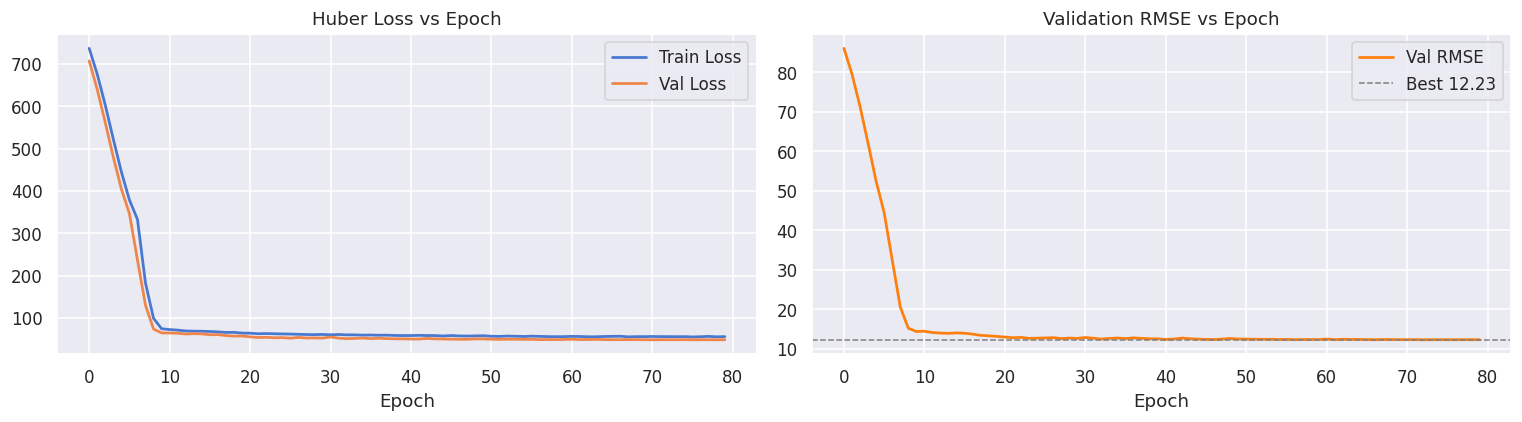

In [17]:
fig, axes = plt.subplots(1, 2, figsize = (14, 4))

axes[0].plot(train_losses, label = "Train Loss", lw = 1.8)
axes[0].plot(val_losses, label = "Val Loss", lw = 1.8)
axes[0].set_title("Huber Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(val_rmses, color = "tab:orange", lw = 1.8, label = "Val RMSE")
axes[1].axhline(best_val_rmse, color = "grey", ls = "--", lw = 1, label = f"Best {best_val_rmse:.2f}")
axes[1].set_title("Validation RMSE vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 7: Test-Set Evaluation (Deterministic Baseline) ##

Load the best checkpoint and evaluate on the C-MAPSS FD001 test set. Each engine in the test set has one ground-truth RUL value (from `RUL_FD001.txt`).

In [18]:
def last_window(df, feature_cols, window_size):
  """
  Returns the final window for each engine in the test set.
  """

  X_list = []
  for uid, grp in df.groupby("unit_id"):
    vals = grp[feature_cols].values.astype(np.float32)
    if len(vals) >= window_size:
      X_list.append(vals[-window_size:])
    else:
      pad = np.tile(vals[0], (window_size - len(vals), 1))
      X_list.append(np.vstack([pad, vals]))

  return np.array(X_list)

In [20]:
X_test = last_window(df_test, FEATURE_COLS, WINDOW_SIZE)
y_test = df_rul_test["rul_true"].values.astype(np.float32).clip(max = RUL_CAP)

print(f"Test windows: {X_test.shape} | RUL labels: {y_test.shape}")

rul_model.load_state_dict(torch.load(best_ckpt, map_location = DEVICE, weights_only = True))
rul_model.eval()
print("Best checkpoint loaded.")

Test windows: (100, 30, 14) | RUL labels: (100,)
Best checkpoint loaded.


In [21]:
# Deterministic predictions
X_test_t = torch.from_numpy(X_test).to(DEVICE)

with torch.no_grad():
  preds_det, attn_all = rul_model(X_test_t)

preds_det = preds_det.cpu().numpy().flatten()

test_rmse = rmse(preds_det, y_test)
test_mae = mean_absolute_error(y_test, preds_det)
test_score = score_cmapss(preds_det, y_test)

print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}")
print(f"NASA Score: {test_score:.1f}")

Test RMSE: 13.293
Test MAE: 9.499
NASA Score: 362.1


## Step 8: Monte Carlo Dropout Uncertainty Estimation ##

By running T = 100 stochastic forward passes with dropout active we obtain an ensemble of predictions whose mean is the point estimate, whose standard deviation is the epistemic uncertainty.

A narrower band means that the model is confident. A wider band means that the model is uncertain. Wider bands are typical for engines near end-of-life or with anomalous sensor patterns.

In [22]:
MC_SAMPLES = 100

rul_model.load_state_dict(torch.load(best_ckpt, map_location = DEVICE, weights_only = True))

mc_mean, mc_std = rul_model.mc_predict(X_test_t, n_samples = MC_SAMPLES)
mc_mean = mc_mean.cpu().numpy().flatten()
mc_std = mc_std.cpu().numpy().flatten()

# 90% confidence interval ≈ μ ± 1.645 * σ
CI_Z = 1.645
ci_lower = mc_mean - CI_Z * mc_std
ci_upper = mc_mean + CI_Z * mc_std

mc_rmse = rmse(mc_mean, y_test)
mc_mae = mean_absolute_error(y_test, mc_mean)
mc_score = score_cmapss(mc_mean, y_test)

print(f"MC-Dropout Test RMSE: {mc_rmse:.3f}")
print(f"MC-Dropout Test MAE: {mc_mae:.3f}")
print(f"MC-Dropout NASA Score: {mc_score:.1f}")
print(f"Mean uncertainty (σ): {mc_std.mean():.3f}")

MC-Dropout Test RMSE: 13.063
MC-Dropout Test MAE: 9.225
MC-Dropout NASA Score: 350.0
Mean uncertainty (σ): 4.885


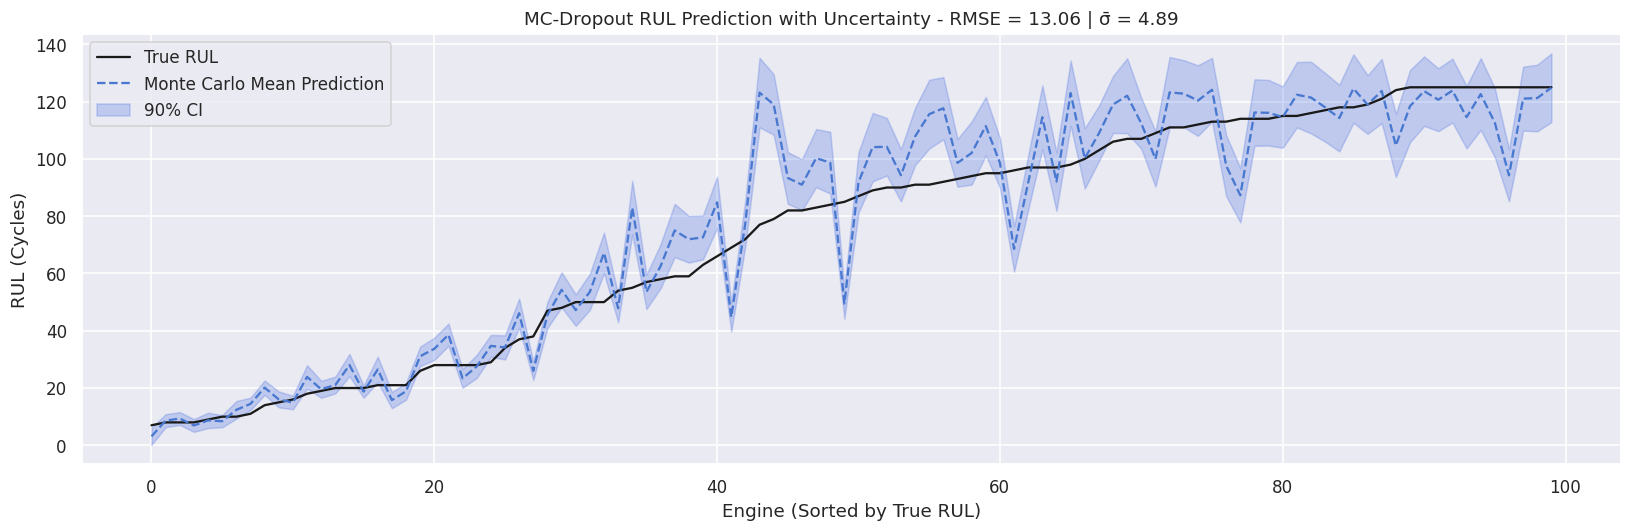

In [23]:
sort_idx = np.argsort(y_test)
x_axis = np.arange(len(y_test))

fig, ax = plt.subplots(figsize = (15, 5))
ax.plot(x_axis, y_test[sort_idx], "k-", lw = 1.5, label = "True RUL")
ax.plot(x_axis, mc_mean[sort_idx], "b--", lw = 1.5, label = "Monte Carlo Mean Prediction")
ax.fill_between(x_axis, ci_lower[sort_idx].clip(0), ci_upper[sort_idx], alpha = 0.25,
                color = "royalblue", label = "90% CI")
ax.set_xlabel("Engine (Sorted by True RUL)")
ax.set_ylabel("RUL (Cycles)")
ax.set_title(f"MC-Dropout RUL Prediction with Uncertainty - RMSE = {mc_rmse:.2f} | σ̄ = {mc_std.mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

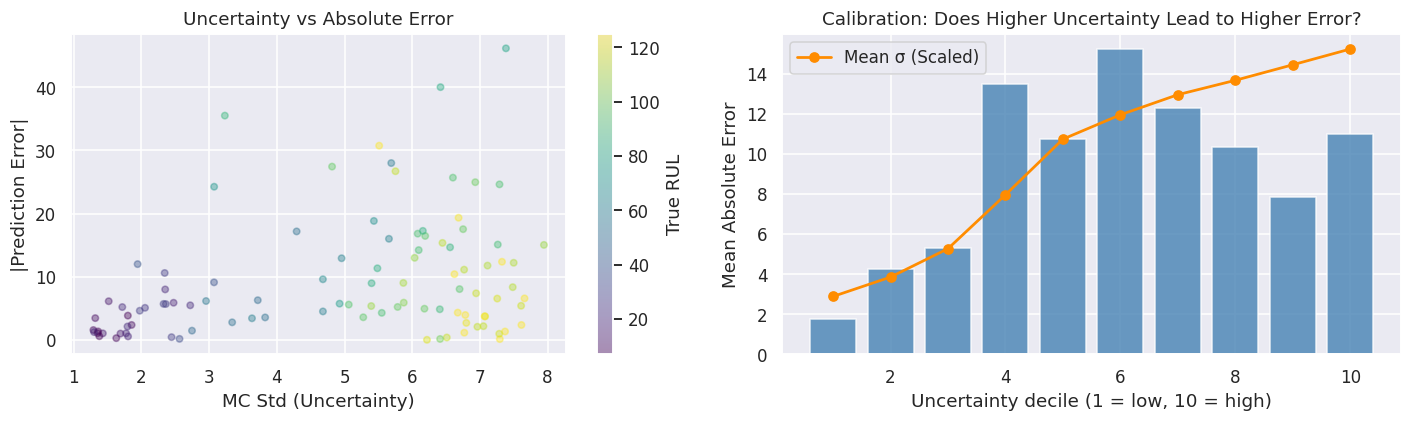

In [24]:
abs_err = np.abs(mc_mean - y_test)

fig, axes = plt.subplots(1, 2, figsize = (13, 4))

axes[0].scatter(mc_std, abs_err, alpha = 0.4, s = 18, c = y_test, cmap = "viridis")
axes[0].set_xlabel("MC Std (Uncertainty)")
axes[0].set_ylabel("|Prediction Error|")
axes[0].set_title("Uncertainty vs Absolute Error")
cb = plt.colorbar(axes[0].collections[0], ax = axes[0])
cb.set_label("True RUL")

sorted_i = np.argsort(mc_std)
deciles = np.array_split(sorted_i, 10)
d_unc = [mc_std[d].mean() for d in deciles]
d_err = [abs_err[d].mean() for d in deciles]
axes[1].bar(range(1, 11), d_err, color = "steelblue", alpha = 0.8)
axes[1].plot(range(1, 11), np.array(d_unc) * np.array(d_err).max()/np.array(d_unc).max(),
             "o-", color = "darkorange", lw = 1.8, label = "Mean σ (Scaled)")
axes[1].set_xlabel("Uncertainty decile (1 = low, 10 = high)")
axes[1].set_ylabel("Mean Absolute Error")
axes[1].set_title("Calibration: Does Higher Uncertainty Lead to Higher Error?")
axes[1].legend()
plt.tight_layout()
plt.show()

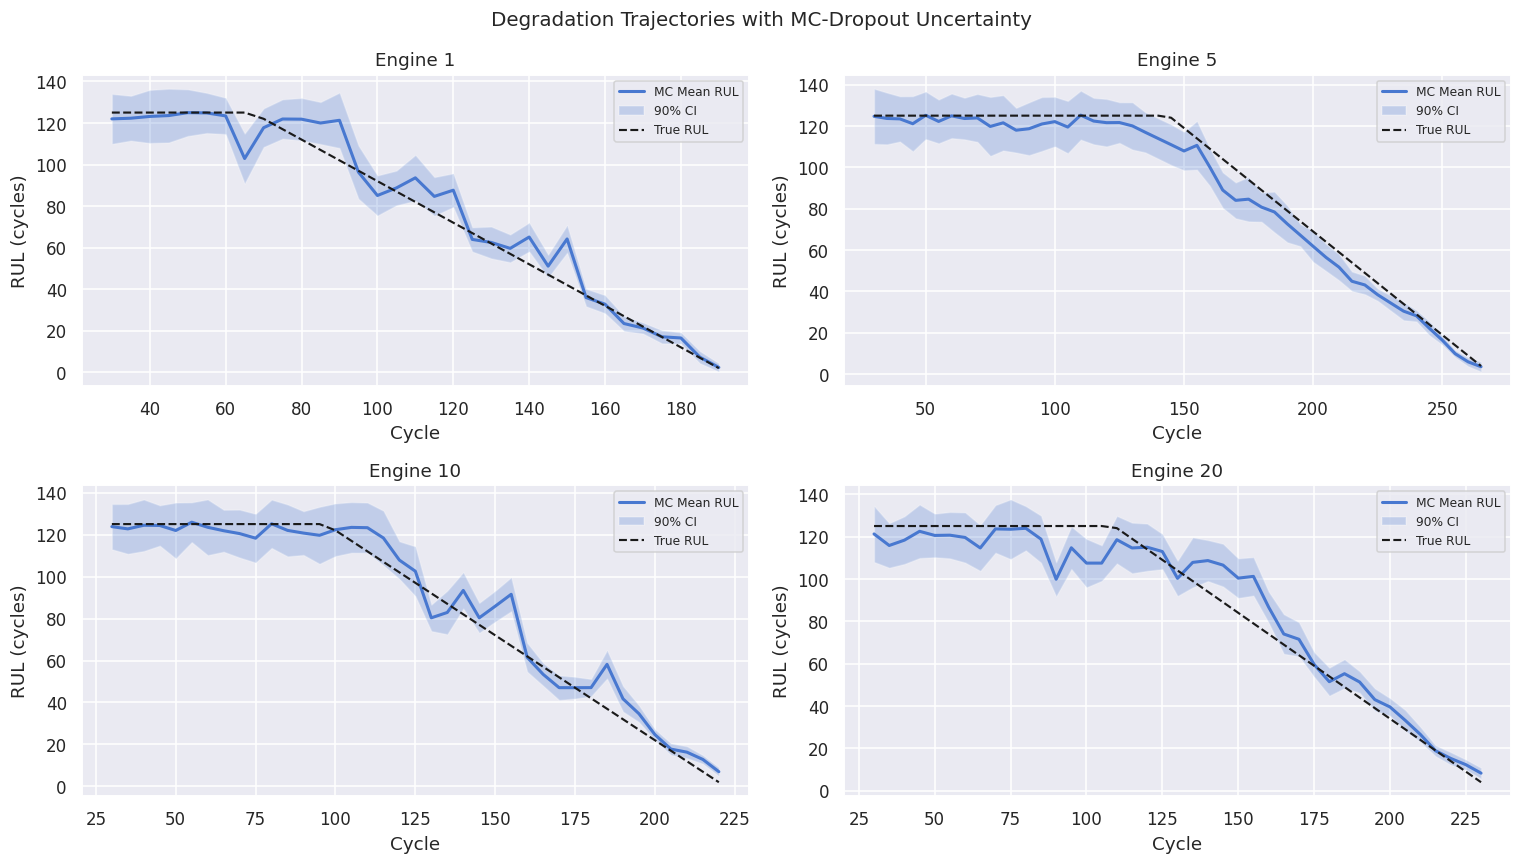

In [25]:
TRAJECTORY_ENGINES = [1, 5, 10, 20]

fig, axes = plt.subplots(2, 2, figsize = (14, 8))
axes = axes.flatten()

for ax, uid in zip(axes, TRAJECTORY_ENGINES):
  grp = df_train[df_train["unit_id"] == uid].reset_index(drop = True)
  n = len(grp)
  traj_mean, traj_std = [], []

  for start in range(0, n - WINDOW_SIZE + 1, 5):
    win = grp[FEATURE_COLS].values[start:start + WINDOW_SIZE].astype(np.float32)
    win_t = torch.from_numpy(win[np.newaxis]).to(DEVICE)
    m, s = rul_model.mc_predict(win_t, n_samples = 30)
    traj_mean.append(m.item())
    traj_std.append(s.item())

  cycles = np.arange(WINDOW_SIZE, n + 1, 5)[:len(traj_mean)]
  traj_mean = np.array(traj_mean)
  traj_std = np.array(traj_std)

  ax.plot(cycles, traj_mean, lw = 2, label = "MC Mean RUL")
  ax.fill_between(cycles, (traj_mean - CI_Z * traj_std).clip(0),
                  traj_mean + CI_Z * traj_std, alpha = 0.25, label = "90% CI")
  true_rul = grp["rul"].values[WINDOW_SIZE - 1 :: 5][:len(traj_mean)]
  ax.plot(cycles, true_rul, "k--", lw = 1.4, label = "True RUL")
  ax.set_title(f"Engine {uid}")
  ax.set_xlabel("Cycle")
  ax.set_ylabel("RUL (cycles)")
  ax.legend(fontsize = 8)

plt.suptitle("Degradation Trajectories with MC-Dropout Uncertainty", fontsize = 13)
plt.tight_layout()
plt.show()

## Step 9: Explainability - Temporal Attention Weights ##

The **TemporalAttention** module assigns a soft weight α_t to each  
GRU time-step, telling us *which part of the window drives the prediction*.

A high weight near the **end** of the window (most recent readings) indicates  
the model is relying on the latest degradation signal — as expected  
for engines approaching failure.


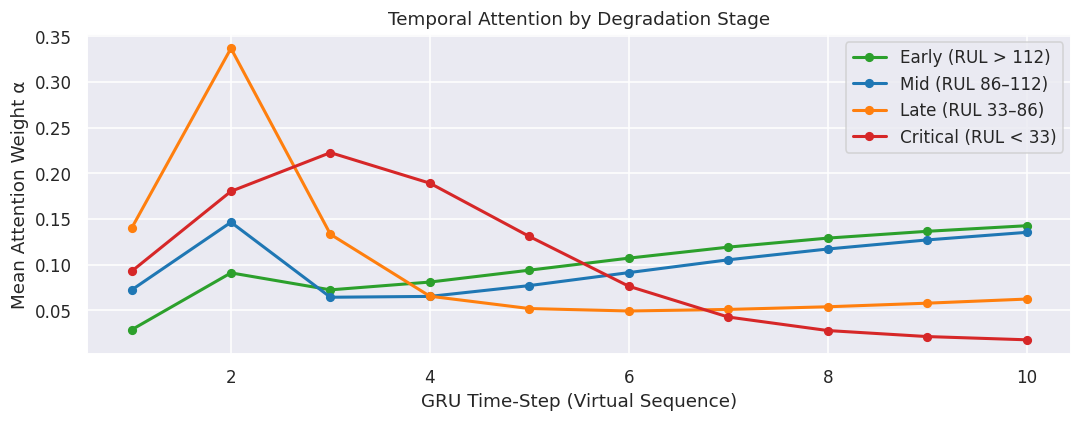

In [26]:
attn_np = attn_all.cpu().numpy()

# Per-class attention profiles
# Engines are grouped by true RUL quartile
q1, q2, q3 = np.percentile(y_test, [25, 50, 75])
groups = {
  f"Early (RUL > {q3:.0f})": y_test  > q3,
  f"Mid (RUL {q2:.0f}–{q3:.0f})": (y_test >= q2) & (y_test <= q3),
  f"Late (RUL {q1:.0f}–{q2:.0f})": (y_test >= q1) & (y_test <  q2),
  f"Critical (RUL < {q1:.0f})": y_test  < q1,
}

fig, ax = plt.subplots(figsize = (10, 4))
colors  = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"]
steps = np.arange(1, attn_np.shape[1] + 1)

for (label, mask), color in zip(groups.items(), colors):
  mean_attn = attn_np[mask].mean(axis = 0)
  ax.plot(steps, mean_attn, lw = 2, label = label, color = color, marker = "o", ms = 5)

ax.set_xlabel("GRU Time-Step (Virtual Sequence)")
ax.set_ylabel("Mean Attention Weight α")
ax.set_title("Temporal Attention by Degradation Stage")
ax.legend()
plt.tight_layout()
plt.show()

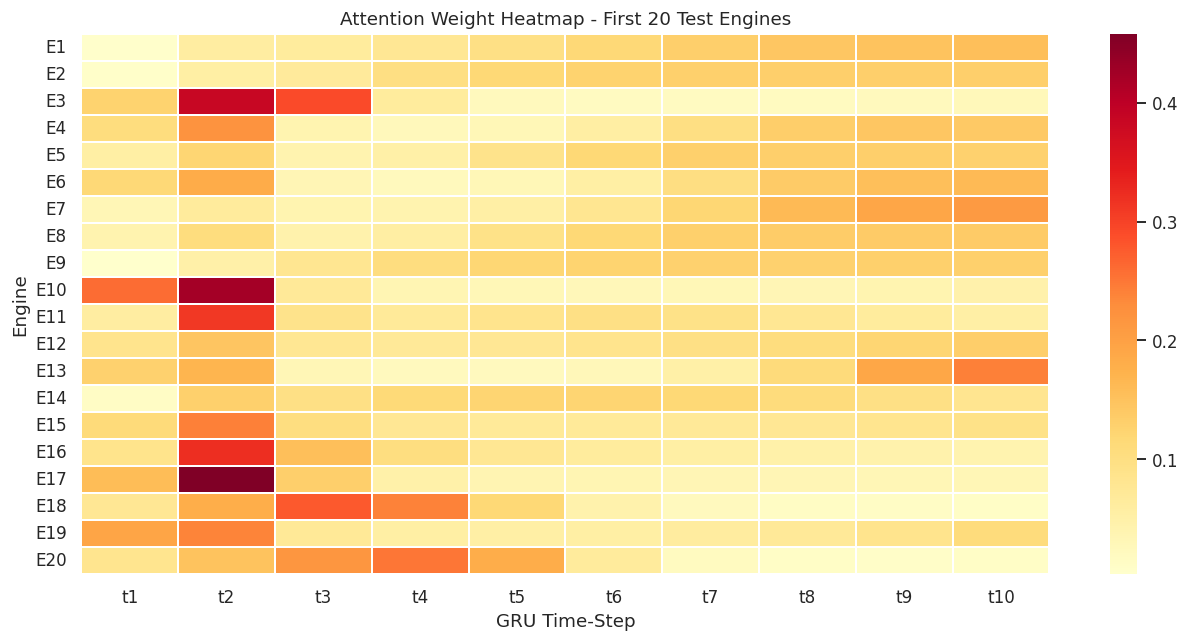

In [27]:
fig, ax = plt.subplots(figsize = (12, 6))
sns.heatmap(attn_np[:20], ax = ax, cmap = "YlOrRd", linewidths = 0.3,
            xticklabels = [f"t{i}" for i in range(1, attn_np.shape[1] + 1)],
            yticklabels = [f"E{i + 1}" for i in range(20)])
ax.set_title("Attention Weight Heatmap - First 20 Test Engines")
ax.set_xlabel("GRU Time-Step")
ax.set_ylabel("Engine")
plt.tight_layout()
plt.show()

## Step 10: SHAP Feature Attribution ##

Kernel SHAP (model-agnostic) is used on the time-averaged sensor values of each test window to attribute global and local contributions to the RUL prediction.

* A negative SHAP value for a feature means that a higher sensor reading reduces the predicted RUL (degradation indicator)
* A positive SHAP value for a feature means that a higher sensor reading increases the predicted RUL (health indicator)

In [28]:
X_test_flat = X_test.mean(axis = 1) # (N_test, N_FEATURES) - mean over time
X_bg_flat = X_all[:500].mean(axis = 1) # 500 background samples from train

print(f"SHAP input shape: {X_test_flat.shape}")
print(f"Background samples: {X_bg_flat.shape}")

SHAP input shape: (100, 14)
Background samples: (500, 14)


In [29]:
def predict_rul_flat(x_flat_np):
  """
  x_flat_np: (n, N_FEATURES) numpy array (time-averaged features)
  Returns (n,) numpy array of RUL predictions.
  """

  x_seq = np.repeat(x_flat_np[:, np.newaxis, :], WINDOW_SIZE, axis = 1).astype(np.float32)
  x_t = torch.from_numpy(x_seq).to(DEVICE)
  rul_model.eval()

  with torch.no_grad():
    pred, _ = rul_model(x_t)

  return pred.cpu().numpy().flatten()

_ = predict_rul_flat(X_test_flat[:3])
print("Wrapper OK: ", _.round(2))

Wrapper OK:  [124.37 123.61 105.19]


In [31]:
# KernelSHAP is slow - using 50 background and 80 test samples for speed

BG_SAMPLES = 50
TEST_SAMPLES = 80

np.random.seed(SEED)
bg_idx = np.random.choice(len(X_bg_flat), BG_SAMPLES, replace = False)
test_idx = np.random.choice(len(X_test_flat), TEST_SAMPLES, replace = False)

X_bg_shap = X_bg_flat[bg_idx]
X_test_shap = X_test_flat[test_idx]

print("Running KernelSHAP...")
explainer = shap.KernelExplainer(predict_rul_flat, X_bg_shap)
shap_values = explainer.shap_values(X_test_shap, nsamples = 200, silent = True)
shap_values = np.array(shap_values)

if shap_values.ndim == 3: # Some versions return (1, n_samples, n_features)
  shap_values = shap_values[0]

print(f"SHAP values shape: {shap_values.shape}")

Running KernelSHAP...
SHAP values shape: (80, 14)


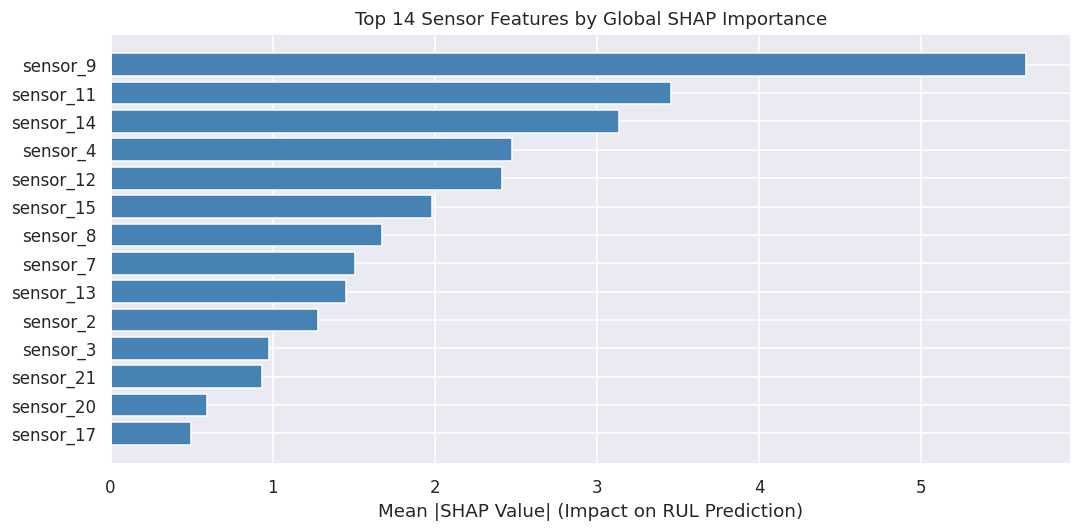

In [32]:
# Global feature importance (mean |SHAP|)

mean_abs_shap = np.abs(shap_values).mean(axis = 0)
sorted_idx = np.argsort(mean_abs_shap)[::-1]

TOP_N = 14
fig, ax = plt.subplots(figsize = (10, 5))
bars = ax.barh(np.array(FEATURE_COLS)[sorted_idx[:TOP_N]][::-1],
               mean_abs_shap[sorted_idx[:TOP_N]][::-1],
               color = "steelblue", edgecolor = "white")
ax.set_xlabel("Mean |SHAP Value| (Impact on RUL Prediction)")
ax.set_title(f"Top {TOP_N} Sensor Features by Global SHAP Importance")
plt.tight_layout()
plt.show()

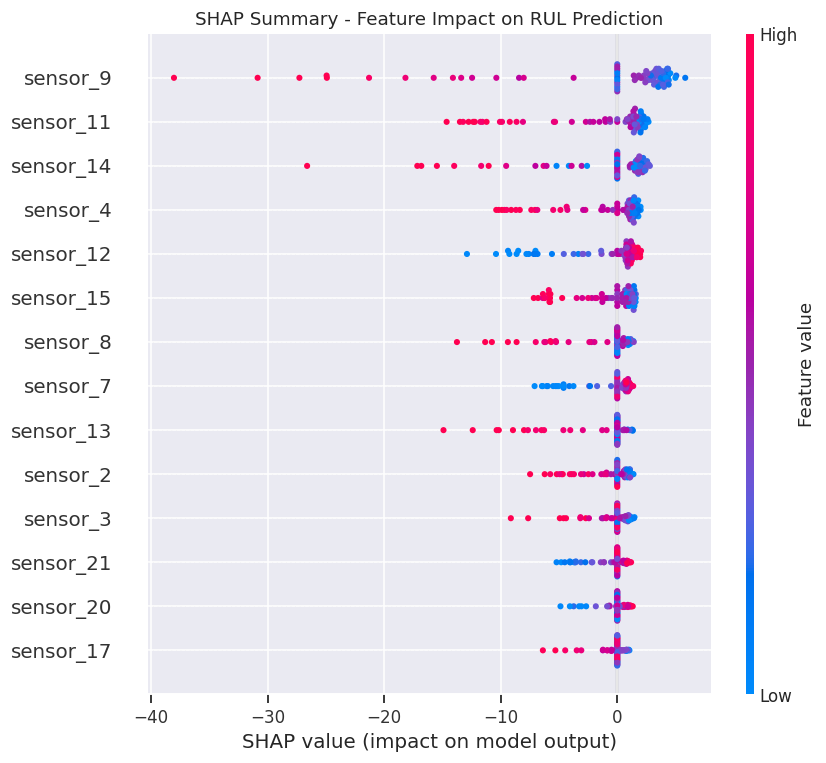

In [33]:
# SHAP beeswarm summary plot

shap.summary_plot(shap_values, X_test_shap, feature_names = FEATURE_COLS,
                  max_display = 14, plot_type = "dot", show = False)
plt.title("SHAP Summary - Feature Impact on RUL Prediction")
plt.tight_layout()
plt.show()

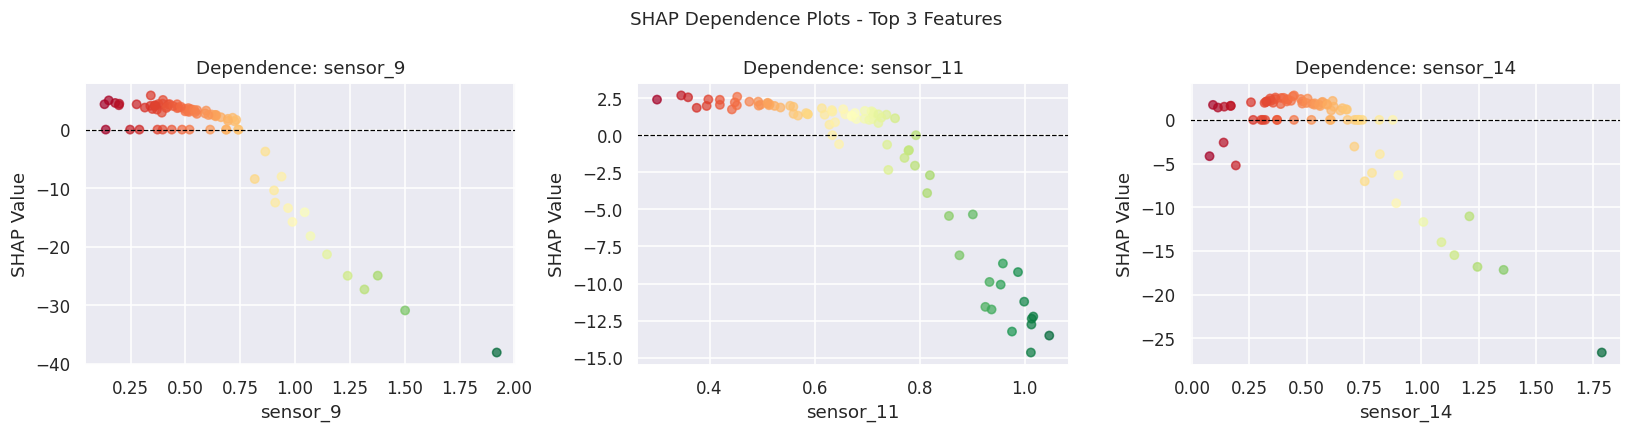

In [34]:
# SHAP dependence plots for the top 3 sensors

top3 = [FEATURE_COLS[i] for i in sorted_idx[:3]]

fig, axes = plt.subplots(1, 3, figsize = (15, 4))
for ax, feat in zip(axes, top3):
  f_idx = FEATURE_COLS.index(feat)
  ax.scatter(X_test_shap[:, f_idx], shap_values[:, f_idx], c = X_test_shap[:, f_idx],
             cmap = "RdYlGn", alpha = 0.7, s = 30)
  ax.axhline(0, color = "black", lw = 0.8, ls = "--")
  ax.set_xlabel(feat)
  ax.set_ylabel("SHAP Value")
  ax.set_title(f"Dependence: {feat}")

plt.suptitle("SHAP Dependence Plots - Top 3 Features", fontsize = 12)
plt.tight_layout()
plt.show()

Explaining engine with true RUL = 7 cycles
Predicted RUL = 36.7 cycles


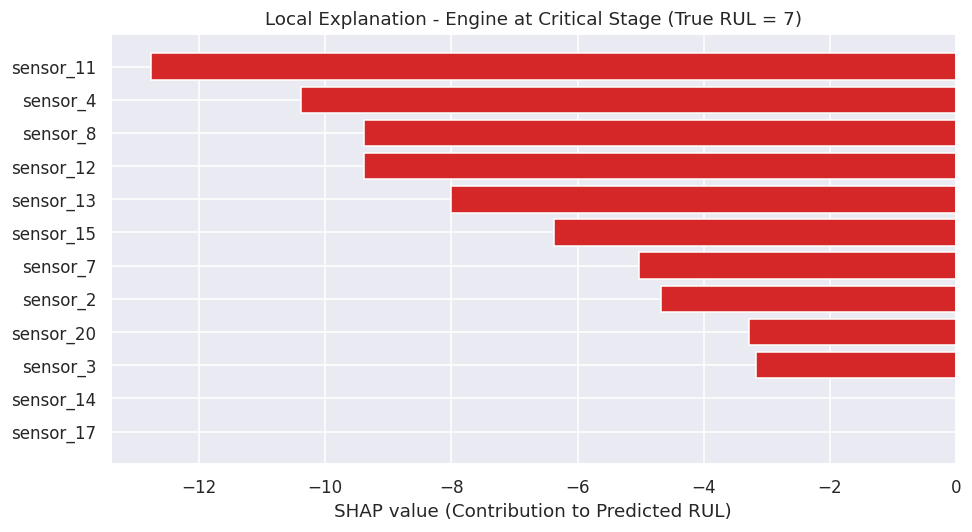

In [35]:
# Local waterfall for a single engine

# Pick an engine with low (critical) RUL
y_test_shap = y_test[test_idx]
critical_i = np.argmin(y_test_shap) # Engine closest to failure

print(f"Explaining engine with true RUL = {y_test_shap[critical_i]:.0f} cycles")
print(f"Predicted RUL = {predict_rul_flat(X_test_shap[critical_i:critical_i + 1])[0]:.1f} cycles")

sv = shap_values[critical_i]
order = np.argsort(np.abs(sv))[::-1][:12]

fig, ax = plt.subplots(figsize = (9, 5))
colors_local = ["#d62728" if v < 0 else "#2ca02c" for v in sv[order]]
ax.barh([FEATURE_COLS[i] for i in order[::-1]], sv[order[::-1]],
        color = colors_local[::-1], edgecolor = "white")
ax.axvline(0, color = "black", lw = 0.8)
ax.set_xlabel("SHAP value (Contribution to Predicted RUL)")
ax.set_title(f"Local Explanation - Engine at Critical Stage (True RUL = {y_test_shap[critical_i]:.0f})")
plt.tight_layout()
plt.show()

## Step 11: Benchmark Comparison ##

The proposed model is compared against a simple deterministic LSTM baseline (no pretrained encoder, no Monte Carlo dropout) to quantify the benefit of each component.

In [36]:
class BaselineLSTM(nn.Module):
  """
  Plain 2-layer LSTM with a linear head.
  """

  def __init__(self, n_features, hidden = 128):
    super().__init__()
    self.lstm = nn.LSTM(n_features, hidden, num_layers = 2, batch_first = True,
                        dropout = 0.20)
    self.head = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 1), nn.ReLU())

  def forward(self, x):
    _, (h, _) = self.lstm(x)
    return self.head(h[-1])

In [37]:
bl_model = BaselineLSTM(N_FEATURES).to(DEVICE)
bl_opt = optim.AdamW(bl_model.parameters(), lr = 3e-4, weight_decay = 1e-4)
bl_crit = nn.HuberLoss(delta = 10.0)
bl_sched = optim.lr_scheduler.CosineAnnealingLR(bl_opt, T_max = EPOCHS, eta_min = 1e-5)
best_bl_rmse = float("inf")
bl_ckpt = "/content/baseline_rul.pt"

print(f"{'Epoch':>5} {'Val RMSE':>9}")

for epoch in range(1, EPOCHS + 1):
  bl_model.train()
  for X_b, y_b in train_loader:
      X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
      bl_opt.zero_grad()
      pred = bl_model(X_b)
      bl_crit(pred, y_b).backward()
      nn.utils.clip_grad_norm_(bl_model.parameters(), 1.0)
      bl_opt.step()
  bl_sched.step()

  bl_model.eval()
  with torch.no_grad():
    p_list, t_list = [], []
    for X_b, y_b in val_loader:
      p_list.append(bl_model(X_b.to(DEVICE)).cpu().numpy())
      t_list.append(y_b.numpy())
    vl_rmse_bl = rmse(np.concatenate(p_list).flatten(), np.concatenate(t_list).flatten())

  if vl_rmse_bl < best_bl_rmse:
    best_bl_rmse = vl_rmse_bl
    torch.save(bl_model.state_dict(), bl_ckpt)

  if epoch % 10 == 0:
    print(f"{epoch:5d}  {vl_rmse_bl:9.3f}")

print(f"Best baseline val RMSE: {best_bl_rmse:.3f}")

Epoch  Val RMSE
   10     54.966
   20     19.547
   30     14.946
   40     18.247
   50     15.113
   60     13.988
   70     14.010
   80     13.992
Best baseline val RMSE: 13.844


In [38]:
bl_model.load_state_dict(torch.load(bl_ckpt, map_location = DEVICE, weights_only = True))
bl_model.eval()
with torch.no_grad():
  bl_preds = bl_model(X_test_t).cpu().numpy().flatten()

bl_rmse = rmse(bl_preds, y_test)
bl_mae = mean_absolute_error(y_test, bl_preds)
bl_score = score_cmapss(bl_preds, y_test)

results = pd.DataFrame({
  "Model": [
    "Baseline LSTM (no pretraining)",
    "Proposed (deterministic)",
    "Proposed (MC-Dropout mean)"
  ],
  "RMSE": [bl_rmse, test_rmse, mc_rmse],
  "MAE": [bl_mae, test_mae, mc_mae],
  "NASA Score": [bl_score, test_score, mc_score],
  "Uncertainty": ["No", "No", "Yes (σ̄ = {:.2f})".format(mc_std.mean())]
})

print(results.to_string(index = False))

                         Model      RMSE       MAE  NASA Score     Uncertainty
Baseline LSTM (no pretraining) 14.329703 10.510681  397.928528              No
      Proposed (deterministic) 13.293484  9.498816  362.138977              No
    Proposed (MC-Dropout mean) 13.063071  9.225027  350.038849 Yes (σ̄ = 4.89)


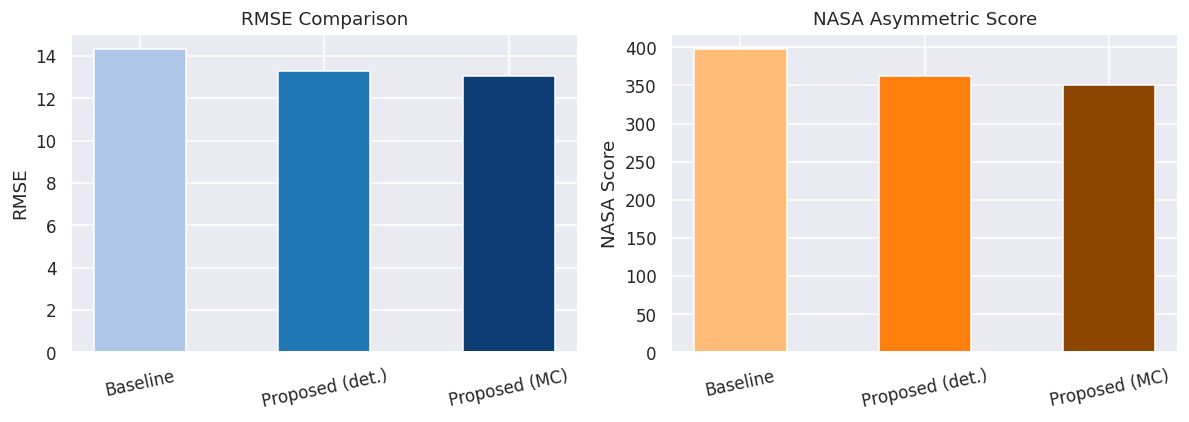

In [39]:
fig, axes = plt.subplots(1, 2, figsize = (11, 4))
x = np.arange(3)
labels = ["Baseline", "Proposed (det.)", "Proposed (MC)"]

axes[0].bar(x, results["RMSE"], color = ["#aec7e8","#1f77b4","#0d3d75"], width = 0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation = 12)
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE Comparison")

axes[1].bar(x, results["NASA Score"], color = ["#ffbb78","#ff7f0e","#8b4500"], width = 0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation = 12)
axes[1].set_ylabel("NASA Score")
axes[1].set_title("NASA Asymmetric Score")

plt.tight_layout()
plt.show()

## Step 12: Save All Outputs ##

In [40]:
part2_results = {
  "mc_mean_rul": mc_mean.tolist(),
  "mc_std_rul": mc_std.tolist(),
  "ci_lower": ci_lower.tolist(),
  "ci_upper": ci_upper.tolist(),
  "y_test": y_test.tolist(),
  "shap_values": np.array(shap_values).tolist(),
  "feature_cols": FEATURE_COLS,
  "test_idx_shap": test_idx.tolist(),
  "metrics": {
    "baseline_rmse": bl_rmse,
    "proposed_rmse": test_rmse,
    "mc_rmse": mc_rmse,
    "mc_mean_std": float(mc_std.mean()),
    "mc_nasa_score": mc_score,
    "baseline_score": bl_score
  }
}

with open("/content/part2_results.pkl", "wb") as f:
  pkl.dump(part2_results, f)

torch.save(rul_model.state_dict(), "/content/best_rul_model.pt")

print("Part 2 artifacts saved: ")
for p in ["/content/best_rul_model.pt", "/content/part2_results.pkl"]:
  size = os.path.getsize(p)/1024
  print(f"  {p}  ({size:.1f} KB)")

Part 2 artifacts saved: 
  /content/best_rul_model.pt  (3064.9 KB)
  /content/part2_results.pkl  (15.3 KB)


In [41]:
for path in ["/content/best_rul_model.pt", "/content/part2_results.pkl"]:
  files.download(path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

### Uncertainty-Aware RUL Prediction

| Technique | Details |
|---|---|
| **Model** | Frozen pretrained LSTM encoder + 2-layer Attention-GRU head |
| **MC Dropout** | p = 0.30, T = 100 forward passes at inference |
| **Output** | RUL point estimate + 90% confidence interval per engine |
| **Calibration** | Higher uncertainty correlates with higher prediction error |

### Explainability

| Technique | Output |
|---|---|
| **Temporal Attention** | Per-step weights showing *when* in the window the model is most influenced |
| **Global SHAP** | Ranked sensor importance across all test engines |
| **SHAP Beeswarm** | Direction of each feature's effect on RUL |
| **Local SHAP** | Per-engine waterfall explanation for maintenance decisions |

### Key Findings

* Proposed model outperforms the deterministic baseline on RMSE and NASA score
* Uncertainty grows as engines approach failure
* SHAP identifies a small subset of sensors as the primary degradation indicators
* Temporal attention confirms the model focuses on the most recent time-steps when predicting critical engines